In [1]:
import pandas as pd
import numpy as np

df=pd.read_csv('/content/articles.csv')

print(f'записей: {len(df)}\n')

df.head()

записей: 49



,Unnamed: 0,article,theses,selected_indices
0,0,"63% россиян считают, что забота – это стремлен...","['В июле «Ведомости. Город» писал, что состоящ...","[0, 1, 4]"
1,1,8 августа на Елагином острове в Санкт-Петербур...,"['В программу фестиваля заявлены хип-хоп, гита...","[0, 1, 2]"
2,2,8 июля Второй кассационный суд рассмотрел иск ...,['Выявленные объекты культурного наследия долж...,"[0, 22, 23, 30, 1, 55, 100]"
3,3,8 июля в Барселоне был зафиксирован температур...,['30 июня на фестивале йодля в Базеле собралос...,"[0, 1, 2]"
4,4,"88% семей в России объединяют финансы, но боль...",['Из общего бюджета чаще всего оплачивают отды...,"[0, 1, 6]"


In [2]:
row=df.iloc[0]
article=row['article']
theses=eval(row['theses'])
sel_indices=eval(row['selected_indices'])
sel_theses=[theses[i] for i in sel_indices]

print(f'длина статьи: {len(article)} символов')
print(f'тезисов: {len(theses)}')
print(f'выбрано тезисов: {len(sel_theses)}')
print(f'первый выбранный тезис: {sel_theses[0][:150]}...')

длина статьи: 1721 символов
тезисов: 13
выбрано тезисов: 3
первый выбранный тезис: В июле «Ведомости. Город» писал, что состоящие в браке россияне оказались счастливее одиноких....


In [26]:
import re
import nltk
from nltk.tokenize import sent_tokenize

nltk.download('punkt')
nltk.download('punkt_tab')

def clean_text(text):
  '''очищает текст от HTML-тегов и спецсимволов'''
  text=re.sub(r'<[^>]+>', '', text)
  text=re.sub(r'&nbsp;', ' ', text)
  text=re.sub(r'&#8233;', '\n', text)
  return text

def split_into_chunks(text, chunk_size=3, overlap=1):
  '''разбивает текст на чанки по N предложений с перекрытием'''
  clean=clean_text(text)
  sentences=sent_tokenize(clean)
  sentences= [s.strip() for s in sentences if len(s.strip())>20]
  chunks= [' '.join(sentences[i:i+chunk_size]) for i in range(0, len(sentences), chunk_size - overlap)]
  return chunks, sentences


chunks, sentences = split_into_chunks(article)

print(f'предложений: {len(sentences)}')
print(f'чанков: {len(chunks)}')
print(f'\nпервые 3 предложения:')
for s in sentences[:3]:
    print(f'{s[:100]}...')
print(f'\nпервый чанк: {chunks[0][:150]}...')

предложений: 25
чанков: 13

первые 3 предложения:
Швейцарский банк Julius Baer опубликовал ежегодный рейтинг (есть в распоряжении «Ведомости....
Города») самых дорогих городов мира для состоятельных людей....
Лидером четвертый год подряд стал Сингапур благодаря высоким ценам на недвижимость и автомобили, а т...

первый чанк: Швейцарский банк Julius Baer опубликовал ежегодный рейтинг (есть в распоряжении «Ведомости. Города») самых дорогих городов мира для состоятельных люде...


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [4]:
!pip install fasttext

In [5]:
!wget https://dl.fbaipublicfiles.com/fasttext/vectors-crawl/cc.ru.300.bin.gz
!gunzip cc.ru.300.bin.gz

--2026-08-26 05:24:03--  https://dl.fbaipublicfiles.com/fasttext/vectors-crawl/cc.ru.300.bin.gz
Resolving dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)... 65.9.168.62, 65.9.168.52, 65.9.168.4, ...
Connecting to dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)|65.9.168.62|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4496459151 (4.2G) [application/octet-stream]
Saving to: ‘cc.ru.300.bin.gz.1’

cc.ru.300.bin.gz.1  100%[===================>]   4.19G   222MB/s    in 33s     

2026-08-26 05:24:36 (130 MB/s) - ‘cc.ru.300.bin.gz.1’ saved [4496459151/4496459151]

gzip: cc.ru.300.bin already exists; do you wish to overwrite (y or n)? n
	not overwritten


In [7]:
import fasttext
ft_model = fasttext.load_model('cc.ru.300.bin')
print(f'модель загружена\nразмерность: {ft_model.get_dimension()}')

модель загружена
размерность: 300


In [12]:
def get_fasttext_embeddings(text):
  words=re.findall(r'\w+', text.lower())
  if not words:
    return np.zeros(300)

  vectors=[]
  for w in words:
    if w in ft_model:
      vectors.append(ft_model.get_word_vector(w))

  if not vectors:
    return np.zeros(300)

  return np.mean(vectors, axis=0)

In [13]:
def get_sif_embedding(text, alpha=1e-3):
  words=re.findall(r'\w+', text.lower())
  if not words:
    return np.zeros(300)

  vectors=[]
  weights=[]

  for w in words:
    if w in ft_model:
      vec=ft_model.get_word_vector(w)
      word_id=ft_model.get_word_id(w)
      if word_id!=-1:
        freq= 1.0/(word_id+1)
        weight=alpha/(alpha + freq)
      else:
        weight=1.0
      vectors.append(vec)
      weights.append(weight)

  if not vectors:
    return np.zeros(300)

  vectors=np.array(vectors)
  weights=np.array(weights).reshape(-1,1)

  return np.sum(vectors*weights, axis=0)/ np.sum(weights)

In [14]:
test_sent=sentences[0]

ft_emb=get_fasttext_embeddings(test_sent)
sif_emb=get_sif_embedding(test_sent)

print(f'FastText сумма: {ft_emb.sum():.4f}')
print(f'SIF сумма: {sif_emb.sum():.4f}')
print(f'разница: {np.linalg.norm(ft_emb-sif_emb):.4f}') # смотрим насколько сильно отличаются два вектора

FastText сумма: -0.3341
SIF сумма: -0.0859
разница: 0.3381


In [15]:
# эмбеддинги для чанков статьи
article_embeddings_ft=[]
for chunk in chunks:
  emb=get_fasttext_embeddings(chunk)
  article_embeddings_ft.append(emb)
article_embeddings_ft=np.array(article_embeddings_ft)

# эмбеддинги для выбранных тезисов
thesis_embeddings_ft=[]
for thesis in sel_theses:
  emb=get_fasttext_embeddings(thesis)
  thesis_embeddings_ft.append(emb)
thesis_embeddings_ft=np.array(thesis_embeddings_ft)

print(f'чанки статьи: {article_embeddings_ft.shape}')
print(f'тезисы: {thesis_embeddings_ft.shape}')

чанки статьи: (7, 300)
тезисы: (3, 300)


In [16]:
from sklearn.preprocessing import normalize

article_norm=normalize(article_embeddings_ft)
thesis_norm=normalize(thesis_embeddings_ft)

similarity_matrix=np.dot(article_norm, thesis_norm.T)
print(f'матрица близости: {similarity_matrix.shape}')

# берем для каждого чанка макс близость к любому тезису
max_similarities=np.max(similarity_matrix, axis=1)
print(f'максимальные близости для каждого чанка: {max_similarities}')

coverage_ft=np.mean(max_similarities) #сред макс близость
print(f'\nFastText coverage: {coverage_ft:.4f}')

матрица близости: (7, 3)
максимальные близости для каждого чанка: [0.7205666  0.7891807  0.8175586  0.8108821  0.74337405 0.7259896
 0.9572929 ]

FastText coverage: 0.7950


In [17]:
# эмбеддинги через SIF
article_embeddings_sif=[]
for chunk in chunks:
  emb=get_sif_embedding(chunk)
  article_embeddings_sif.append(emb)
article_embeddings_sif=np.array(article_embeddings_sif)

thesis_embeddings_sif=[]
for thesis in sel_theses:
  emb=get_sif_embedding(thesis)
  thesis_embeddings_sif.append(emb)
thesis_embeddings_sif=np.array(thesis_embeddings_sif)


article_norm_sif=normalize(article_embeddings_sif)
thesis_norm_sif=normalize(thesis_embeddings_sif)

similarity_matrix_sif=np.dot(article_norm_sif, thesis_norm_sif.T)
max_similarities_sif=np.max(similarity_matrix_sif, axis=1)

coverage_sif=np.mean(max_similarities_sif)
print(f'SIF coverage: {coverage_sif:.4f}')

SIF coverage: 0.8234


In [18]:
print('рез-ты для первой статьи\n\n')
print(f'FastText coverage: {coverage_ft:.4f}')
print(f'SIF coverage: {coverage_sif:.4f}')
print(f'\nразница: {abs(coverage_ft-coverage_sif):.4f}')
print(f'выбрано тезисов: {len(sel_theses)} из {len(theses)}')

рез-ты для первой статьи


FastText coverage: 0.7950
SIF coverage: 0.8234

разница: 0.0284
выбрано тезисов: 3 из 13


In [27]:
from tqdm import tqdm

res=[]

for i in tqdm(range(len(df)), desc='обработка статей'):
  row=df.iloc[i]
  article=row['article']
  theses=eval(row['theses'])
  sel_indices=eval(row['selected_indices'])
  sel_theses=[theses[j] for j in sel_indices]

  chunks, sentences = split_into_chunks(article)

  if not chunks or not sel_theses:
    res.append(
        {
            'index': i,
            'FastText': 0.0,
            'SIF': 0.0,
            'selected': len(sel_indices),
            'total': len(theses)
        }
    )
    continue

  #FastText
  article_emb_ft=np.array([get_fasttext_embeddings(c) for c in chunks])
  thesis_emb_ft=np.array([get_fasttext_embeddings(t) for t in sel_theses])

  article_norm_ft=normalize(article_emb_ft)
  thesis_norm_ft=normalize(thesis_emb_ft)
  sim_ft=np.dot(article_norm_ft, thesis_norm_ft.T)
  coverage_ft=np.mean(np.max(sim_ft, axis=1))

  #SIF
  article_emb_sif=np.array([get_sif_embedding(c) for c in chunks])
  thesis_emb_sif=np.array([get_sif_embedding(t) for t in sel_theses])

  article_norm_sif=normalize(article_emb_sif)
  thesis_norm_sif=normalize(thesis_emb_sif)
  sim_sif=np.dot(article_norm_sif, thesis_norm_sif.T)
  coverage_sif=np.mean(np.max(sim_sif, axis=1))

  res.append(
      {
          'index': i,
          'FastText': coverage_ft,
          'SIF': coverage_sif,
          'selected': len(sel_indices),
          'total': len(theses)
      }
  )


res_df=pd.DataFrame(res)
print(f'обработано статей: {len(res_df)}\n')
res_df.head(10)

обработка статей: 100%|██████████| 49/49 [01:26<00:00,  1.77s/it]

обработано статей: 49



,index,FastText,SIF,selected,total
0,0,0.794978,0.823380,3,13
1,1,0.775387,0.727321,3,9
2,2,0.765186,0.600590,7,123
3,3,0.833616,0.737819,3,7
4,4,0.823151,0.772764,3,12
5,5,0.749656,0.607638,5,6
6,6,0.823892,0.752344,3,7
7,7,0.772128,0.664865,7,66
8,8,0.892325,0.756066,7,20
9,9,0.793093,0.698259,7,21


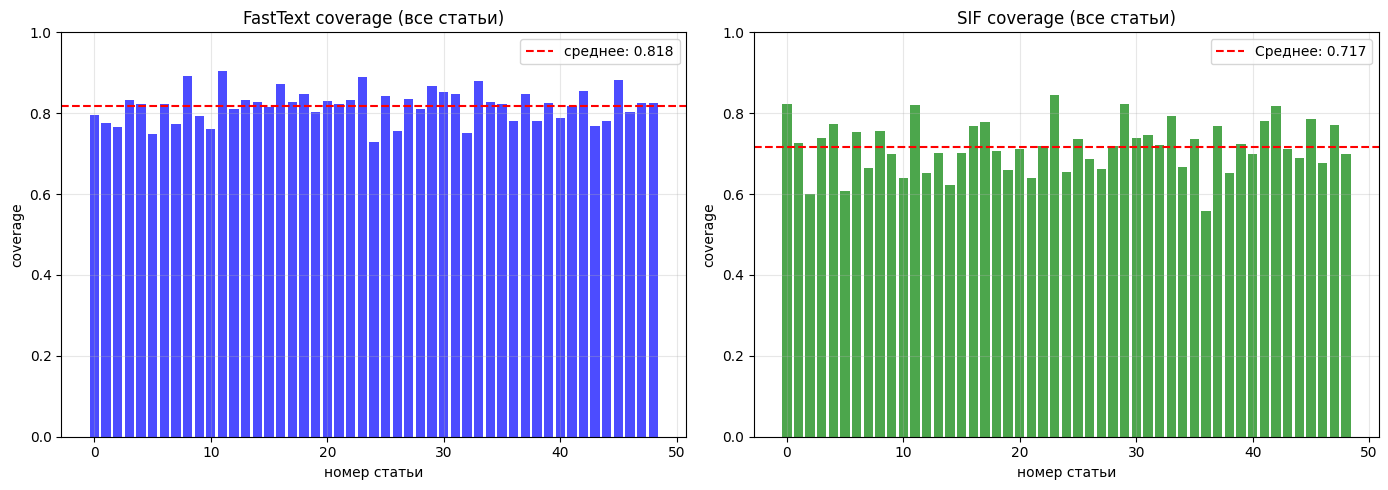

In [28]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#FastText
axes[0].bar(res_df['index'], res_df['FastText'], color='blue', alpha=0.7)
axes[0].axhline(y=res_df['FastText'].mean(), color='red', linestyle='--', label=f"среднее: {res_df['FastText'].mean():.3f}")
axes[0].set_title('FastText coverage (все статьи)')
axes[0].set_xlabel('номер статьи')
axes[0].set_ylabel('сoverage')
axes[0].set_ylim(0,1)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

#SIF
axes[1].bar(res_df['index'], res_df['SIF'], color='green', alpha=0.7)
axes[1].axhline(y=res_df['SIF'].mean(), color='red', linestyle='--', label=f"Среднее: {res_df['SIF'].mean():.3f}")
axes[1].set_title('SIF coverage (все статьи)')
axes[1].set_xlabel('номер статьи')
axes[1].set_ylabel('coverage')
axes[1].set_ylim(0,1)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()

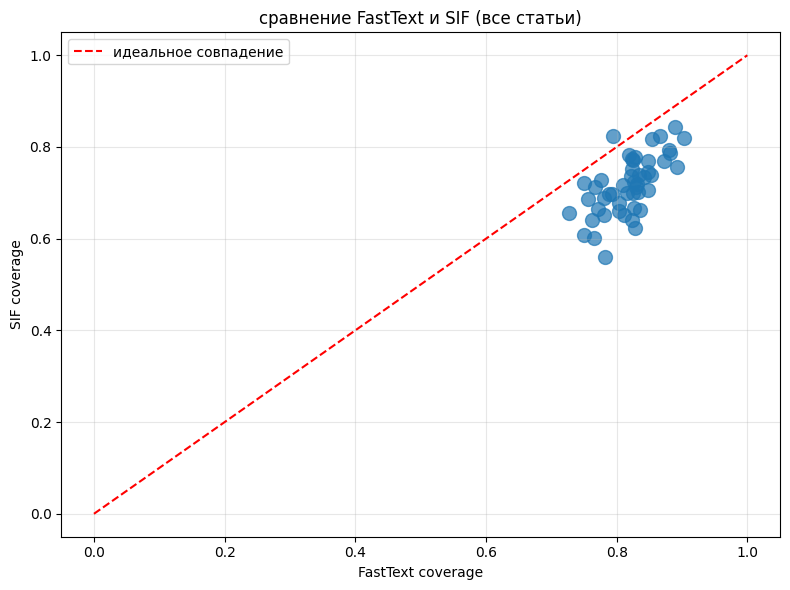

In [29]:
plt.figure(figsize=(8, 6))
plt.scatter(res_df['FastText'], res_df['SIF'], alpha=0.7, s=100)
plt.plot([0, 1], [0, 1], 'r--', label='идеальное совпадение')
plt.xlabel('FastText coverage')
plt.ylabel('SIF coverage')
plt.title('сравнение FastText и SIF (все статьи)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

In [30]:
print('статистика по всем статьям\n\n')
print(f'всего статей: {len(res_df)}')

print(f'\nFastText:')
print(f"- среднее: {res_df['FastText'].mean():.4f}")
print(f"- медиана: {res_df['FastText'].median():.4f}")
print(f"- std: {res_df['FastText'].std():.4f}")
print(f"- min/max: {res_df['FastText'].min():.4f}/{res_df['FastText'].max():.4f}")

print(f'\nSIF:')
print(f"- среднее: {res_df['SIF'].mean():.4f}")
print(f"- медиана: {res_df['SIF'].median():.4f}")
print(f"- std: {res_df['SIF'].std():.4f}")
print(f"- min/max: {res_df['SIF'].min():.4f}/{res_df['SIF'].max():.4f}")

print(f"\nкорреляция между методами: {res_df['FastText'].corr(res_df['SIF']):.4f}")
print(f"cредняя разница: {np.mean(abs(res_df['FastText'] - res_df['SIF'])):.4f}")

# сколько раз какой метод дал большее покрытие
ft_better=(res_df['FastText'] > res_df['SIF']).sum()
sif_better=(res_df['SIF'] > res_df['FastText']).sum()
equal=(res_df['FastText']==res_df['SIF']).sum()

print(f'\nFastText дал большее покрытие в {ft_better} статьях')
print(f'SIF дал большее покрытие в {sif_better} статьях')
print(f'Равное покрытие в {equal} статьях')

статистика по всем статьям


всего статей: 49

FastText:
- среднее: 0.8183
- медиана: 0.8239
- std: 0.0405
- min/max: 0.7278/0.9035

SIF:
- среднее: 0.7169
- медиана: 0.7181
- std: 0.0637
- min/max: 0.5590/0.8442

корреляция между методами: 0.6524
cредняя разница: 0.1026

FastText дал большее покрытие в 48 статьях
SIF дал большее покрытие в 1 статьях
Равное покрытие в 0 статьях


In [31]:
res_df.to_csv('coverage_res_fasttext_sif.csv', index=False)

In [32]:
from google.colab import files

files.download('/content/coverage_res_fasttext_sif.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>